# **Time Series Decomposition**

## <span style="color:grey;"> **1. Time Series Components** </span>

#### Load Common libraries and settings

In [149]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
import numpy as np
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

#### Load additional libraries

In [4]:
import calendar

from coreforecast.scalers import boxcox, boxcox_lambda
from statsmodels.tsa.seasonal import STL, seasonal_decompose

#### **Decomposition of time series components**

The time can be decomposed with the following models:

- Additive decomposition
- Multiplicative decomposition
- Pseudoadditive decomposition

**Additive Model**

Additive models assume that the observed time series is the sum of its components:

$$X(t) = T(t) + S(t) + R(t)$$
where $X(t)$ is the data, $S(t)$ is the seasonal component, $T(t)$ is the trend-cycle component, and $R(t)$ is the remainder component, all at period t. Additive models are used when the magnitudes of the seasonal and residual values do not depend on the level of the trend.

**Multiplicative Model**

Assumes that the observed time series is the product of its components:
$$X(t) = T(t) * S(t) * R(t)$$
When the variation in the seasonal pattern, or the variation around the trend-cycle, appears to be proportional to the level of the time series, then a multiplicative decomposition is more appropriate. Multiplicative decompositions are common with economic time series.

An alternative to using a multiplicative decomposition is to first transform the data until the variation in the series appears to be stable over time, then use an additive decomposition. When a log transformation has been used, this is equivalent to using a multiplicative decomposition on the original data because
$$log(X_t) = log(T_t) + log(S_t) + log(R_t)$$

**Pseudoadditive Model**

Pseudoadditive models combine elements of the `additive` and `multiplicative` models. It is useful when:
- Time series values are close to or equal to zero. Multiplicative models struggle with zero values, but you still need to model multiplicative seasonality.
- Some features are multiplicative (e.g., seasonal effects) and other are additive (e.g., residuals).
- Complex seasonal patterns or data that do not completely align with additive or multiplicative model.

For example, this model is particularly relevant for modeling series that:
- are extremely weather-dependent,
- have sharply pronounced seasonal fluctuations and trend-cycle movements.

The formulation of such models are as follows:
$$X(t) = T(t) + T(t) \cdot (S(t)-1) + T(t) \cdot (R(t)-1) = T(t) \cdot (S(t) + R(t) - 1)$$

Let us now look at a simple example to build **three different time series** using these models.

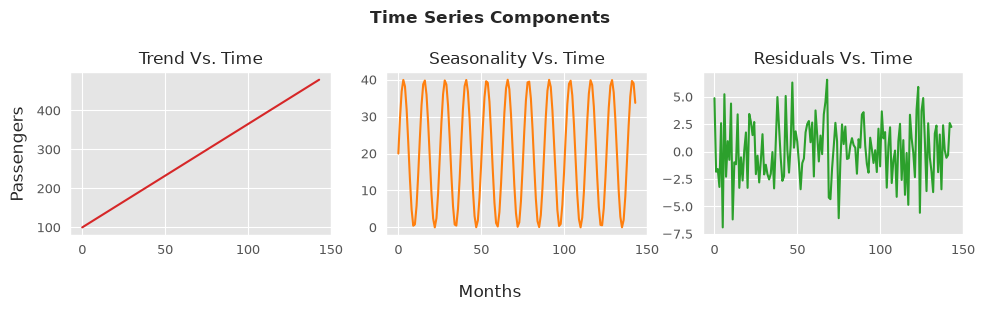

In [5]:
time = np.arange(144)
trend = time * 2.65 +100
seasonal = 20 + np.sin( time * 0.5) * 20
residuals = np.random.normal(loc=0.0, scale=3, size=len(time))

fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[0].plot(time, trend, color='tab:red')
ax[1].plot(time, seasonal, color='tab:orange')
ax[2].plot(time, residuals, color='tab:green')
ax[0].set_title("Trend Vs. Time")
ax[1].set_title("Seasonality Vs. Time")
ax[2].set_title("Residuals Vs. Time")

for a in ax:
    a.grid(True)

fig.supxlabel('Months')
fig.supylabel('Passengers')
fig.suptitle('Time Series Components',fontweight='bold')
fig.tight_layout()

plt.show()

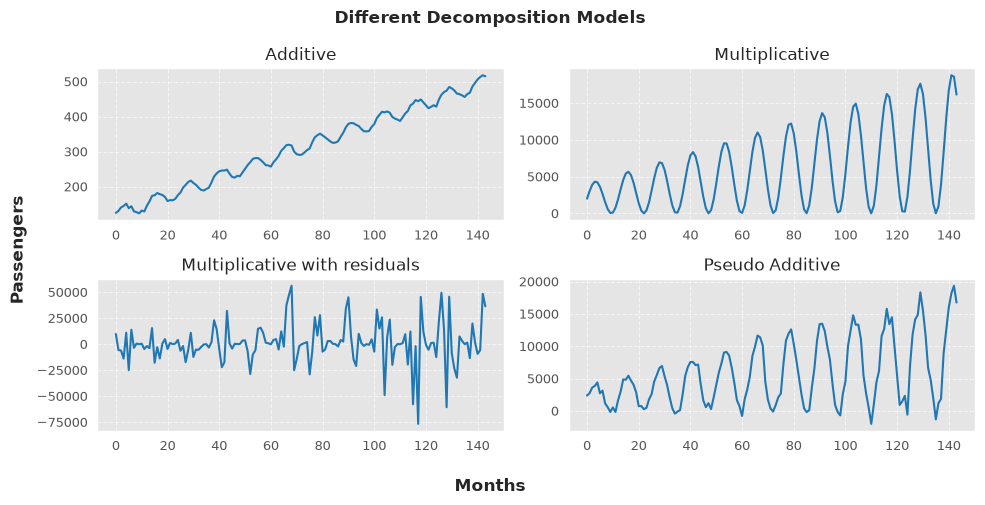

In [6]:
additive = trend + seasonal + residuals
multiplicative_wr = trend * seasonal * residuals
multiplicative = trend * seasonal ## series without residuals make the pattern clearer
pseudo_additive = trend * (seasonal + residuals-1)

fig, ax = plt.subplots(2,2,figsize=(10,5))
ax[0,0].plot(time,additive,'tab:blue')
ax[0,1].plot(time,multiplicative,'tab:blue')
ax[1,0].plot(time,multiplicative_wr,'tab:blue')
ax[1,1].plot(time,pseudo_additive,'tab:blue')

ax[0,0].set_title("Additive")
ax[0,1].set_title("Multiplicative")
ax[1,0].set_title("Multiplicative with residuals")
ax[1,1].set_title("Pseudo Additive")

for a in ax.flat:
    a.grid(True, linestyle='--', alpha=0.6)

fig.supxlabel("Months",fontweight='bold')
fig.supylabel("Passengers",fontweight='bold')
fig.suptitle("Different Decomposition Models",fontweight='bold')
fig.tight_layout()

plt.show()

#### **Different Decomposition Techniques**

##### **1. Classical Decomposition**
<hr style="margin-top: -20px; border: none; border-top: 1px solid lightgrey;">
The classical decomposition method originated in the 1920s. It is a relatively simple procedure, and forms the starting point for most other methods of time series decomposition. There are two forms of classical decomposition: an additive decomposition and a multiplicative decomposition. These are described below for a time series with seasonal period $m$ (e.g., $m = 4$ for quarterly data, $m = 12$ for monthly data, $m = 7$ for daily data with a weekly pattern).

In classical decomposition, we assume that the seasonal component is constant from year to year. For multiplicative seasonality, the $m$ values that form the seasonal component are sometimes called the `“seasonal indices”`.

The **`Statsmodels`** library provides an implementation of the naive, or classical decomposition method in a function called `seasonal_decompose()`. It requires that you specify whether the model is additive or multiplicative.

We will look at the application of this classical decomposition for obtaining the components $T_t$, $S_t$ and $R_t$ using an example. We will decompose the monthly total number of persons in thousands employed in the retail sector across the US since 1990.

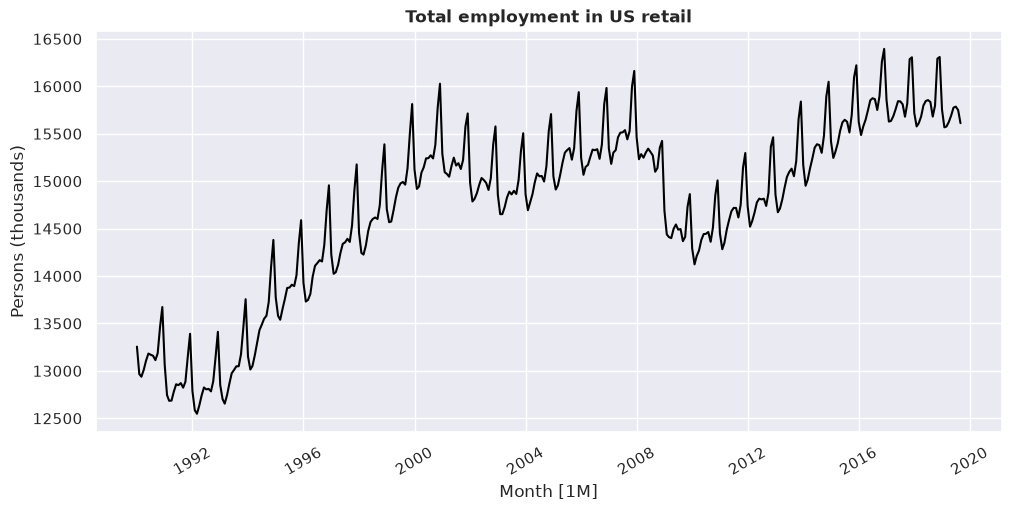

In [146]:
us_employment = pd.read_csv("data/us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[lambda x:
    (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")]

fig = plot_series_utils(us_retail_employment)
fig.set_size_inches(10, 5)

ax=fig.gca()

ax.set_xlabel("Month [1M]")
ax.set_ylabel("Persons (thousands)")
ax.set_title("Total employment in US retail",fontweight='bold')
fig.legends.clear()

fig

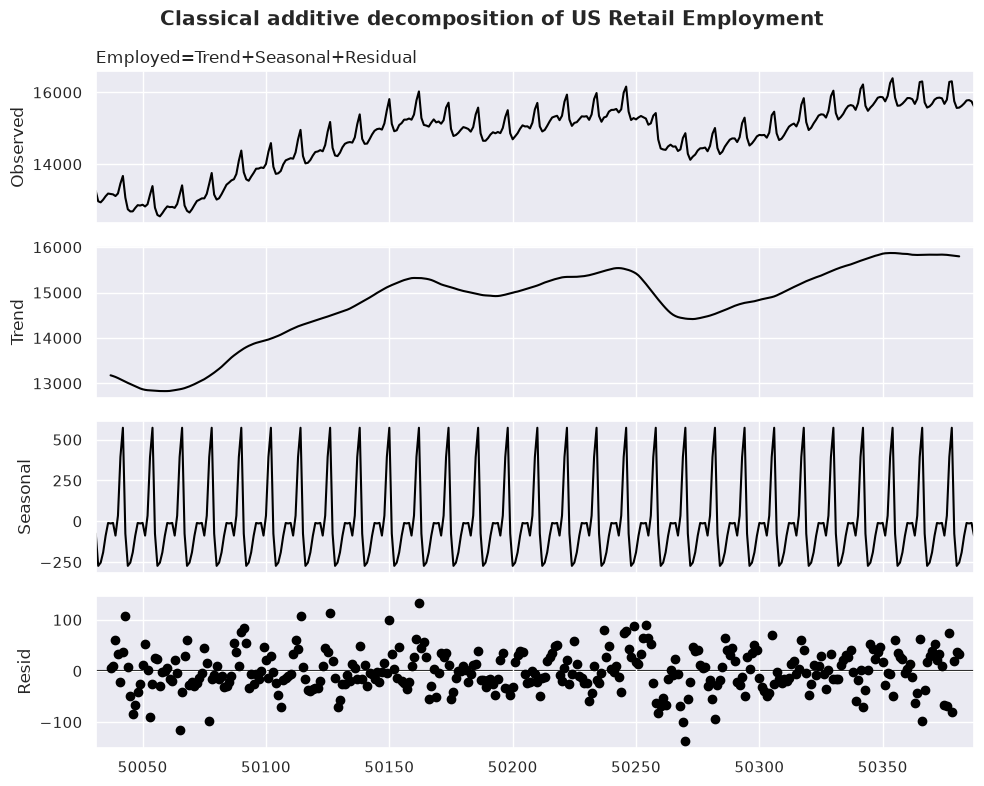

In [132]:
from statsmodels.tsa.seasonal import seasonal_decompose

additive_decomp = seasonal_decompose(us_retail_employment["y"].rename(""),model="additive",period=12)

# Plot decomposition 
fig = additive_decomp.plot()
fig.set_size_inches(10, 8)

# Adjust plot styling
for ax in fig.axes:
    ax.grid(True)
    ax.tick_params(axis="x", rotation=0)

fig.axes[0].set_title("Employed=Trend+Seasonal+Residual",loc='left')
fig.axes[0].set_ylabel("Observed")
plt.suptitle("Classical additive decomposition of US Retail Employment",fontweight='bold',ha='center')
plt.tight_layout()
plt.show()

##### **LOESS**
<hr style="margin-top: -20px; border: none; border-top: 1px solid lightgrey;">
Before we discuss about the next decomposition method, it is important to understand the `LOESS` method as this is the foundation for our next decomposition method **STL**. Loess is a method used to fit a smooth curve to scatterplots (which is why it is known as _Locally Estimated Scatterplot Smoothing_). Loess computes the smooth curve at any given point by fitting a polynomial to a window of data around that point. This gives us two important arguments: the **window size**, which determines how smooth the fit is, and the **degree of the polynomial** (typically this is 0 or 1). The curve that Loess fits through a time series can be used to model the trend of a time series.

We will use the example of `US monthly Retail Sales data` to demonstrate the effect of LOESS with different window sizes. The `Statsmodels` provide the function `lowess` which can be called from the `nonparametric` class of functions.

In [ ]:
import requests
from io import StringIO

url = "https://www.census.gov/retail/marts/www/adv44X72.txt"
r = requests.get(url)

retail_sales = pd.read_fwf(StringIO(r.text[28:4405]))
seasonal_factors = pd.read_fwf(StringIO(r.text[4550:8965]))
retail_sales[retail_sales.columns[1:]] = retail_sales[retail_sales.columns[1:]]*seasonal_factors[seasonal_factors.columns[1:]]

retail_sales.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,142622.592,142314.966,154998.119,158481.711,164643.246,163623.075,164809.260,165173.004,160087.614,168387.882,166456.248,202738.419
1,1993,149668.500,145540.080,165837.498,171069.388,176419.200,176132.324,178107.686,178211.961,172369.408,177410.412,182454.370,219284.247
2,1994,157522.355,158016.163,187094.442,183626.655,189328.320,191743.800,187873.938,196494.130,188733.300,192362.688,197730.225,234901.495
3,1995,171615.408,167196.888,195374.179,190622.560,204794.040,205793.341,197716.230,208517.886,196706.249,198791.627,207208.810,240961.792
4,1996,180764.391,187015.000,205988.800,205526.708,220659.065,211568.740,211881.135,219912.378,204277.214,216819.156,217749.004,253004.370


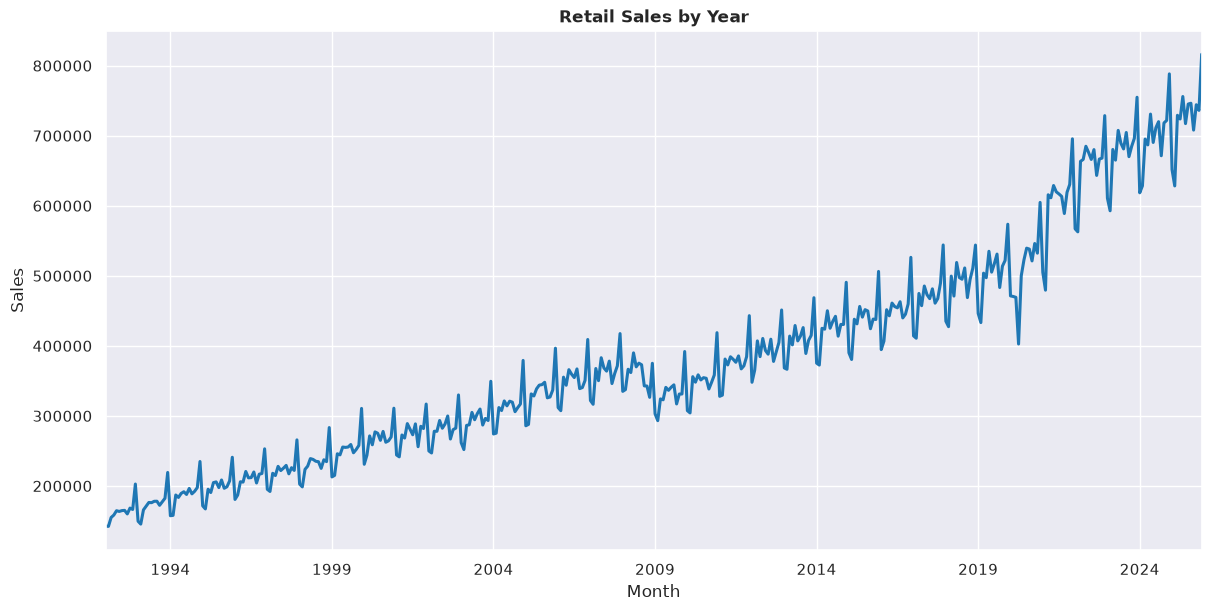

In [90]:
retail_sales_ts = retail_sales.melt(id_vars='YEAR',
            var_name='Month',
            value_name='Retail_Sales')

retail_sales_ts['Date'] = pd.to_datetime(retail_sales_ts['YEAR'].astype(str) + '-' 
                                         + retail_sales_ts['Month'], format='%Y-%b')

retail_sales_ts.sort_values(by="Date", inplace=True)

retail_sales_ts.set_index('Date')["Retail_Sales"].plot(figsize=(12,6),
                                                       color='tab:blue',
                                                       linewidth=2.2,
                                                        legend=False)
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Retail Sales by Year",fontweight='bold')
plt.show()

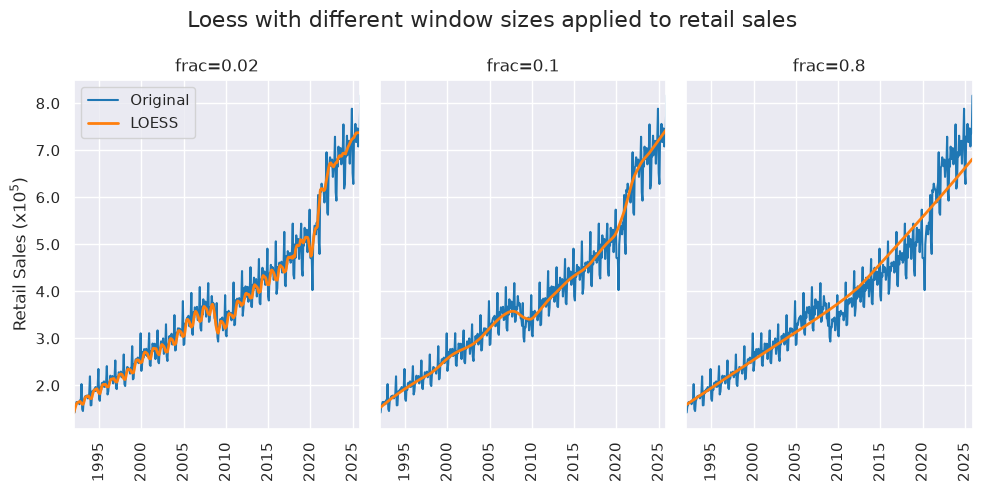

In [ ]:
import statsmodels.api as sm
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

sns.set_style("darkgrid")
sns.set_context('notebook')

# Create LOWESS smoothings with different frac values
frac_values = [0.02, 0.1, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

for ax, frac in zip(axes, frac_values):
    # Compute LOWESS smoothing
    smoothed = sm.nonparametric.lowess(exog=retail_sales_ts['Date'],
                                       endog=retail_sales_ts['Retail_Sales'],frac=frac)

    retail_sales_ts[f'smoothed_{frac}'] = smoothed[:, 1]

    # Plot original
    ax.plot(retail_sales_ts['Date'], retail_sales_ts['Retail_Sales'], 
        color='tab:blue', 
        linewidth=1.5, 
        label="Original")
    
    #Plot smoothed
    ax.plot(retail_sales_ts['Date'], retail_sales_ts[f'smoothed_{frac}'], 
        color='tab:orange', 
        linewidth=2, 
        label="LOESS")

    ax.set_title(f"frac={frac}")
    ax.grid(True)

axes[0].legend(["Original", "LOESS"])
axes[0].set_ylabel("Retail Sales (x$10^5$)")

for ax in axes:
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{x/1e5}'))
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(retail_sales_ts['Date'].min(), retail_sales_ts['Date'].max())
    ax.tick_params(axis='x',rotation=90)

# Chart Title
fig.suptitle(
    "Loess with different window sizes applied to retail sales",
    fontsize=16,
    y=0.98
)

plt.tight_layout()
plt.show()
    

We see that Loess is able to capture the trend of a retail sales time series when an appropriate window size is selected. When the window size parameter (provided by the argument `frac`) is too small (frac=0.02) we see that Loess overfits (orange) to the seasonality, when the window size is too large (frac=0.8) it underfits the data, and when a good window size is chosen (frac=0.1) Loess captures the overall trend of the time series.

##### **2. STL Decomposition**
<hr style="margin-top: -20px; border: none; border-top: 1px solid lightgrey;">
STL (acronym for <span style="color:blue">"Seasonal and Trend decomposition using Loess"</span>) is a versatile and robust method for decomposing time series. The STL method was developed by Cleveland et al. (1990), and later extended to handle multiple seasonal patterns by Bandara et al. (2025).

STL has several <u>advantages</u> over classical decomposition which are as follows:
1. STL will handle any type of seasonality, not only monthly and quarterly data.
2. The seasonal component is allowed to change over time, and the rate of change can be controlled by the user.
3. The smoothness of the trend-cycle can also be controlled by the user.
4. It can be robust to outliers (i.e., the user can specify a robust decomposition), so that occasional unusual observations will not affect the estimates of the trend-cycle and seasonal components. 

On the other hand, STL has some <u>disadvantages</u>. In particular, it does not handle trading day or calendar variation automatically, and it only provides facilities for additive decompositions.

<div style="background-color: #e7f2fa; border-left: 5px solid #2980b9; padding: 10px 12px; margin: 1px 0; border-radius: 4px;max-width: 1100px;">

  <strong>Points to be Noted:</strong><br>
  A multiplicative decomposition can be obtained by first taking logs of the data, then back-transforming the components. <br><br>
  Decompositions that are between additive and multiplicative can be obtained using a Box-Cox transformation of the data with $0 < \lambda < 1$. 
  A value of $λ=0$ gives a multiplicative decomposition while $λ=1$ gives an additive decomposition.

</div>

We are going to apply the `STL Decomposition` on our previous `US Retail Employment` dataset. First, we will use the default values of the function and then apply the decomposition. Remember, this technique is only applicable for **additive models**.

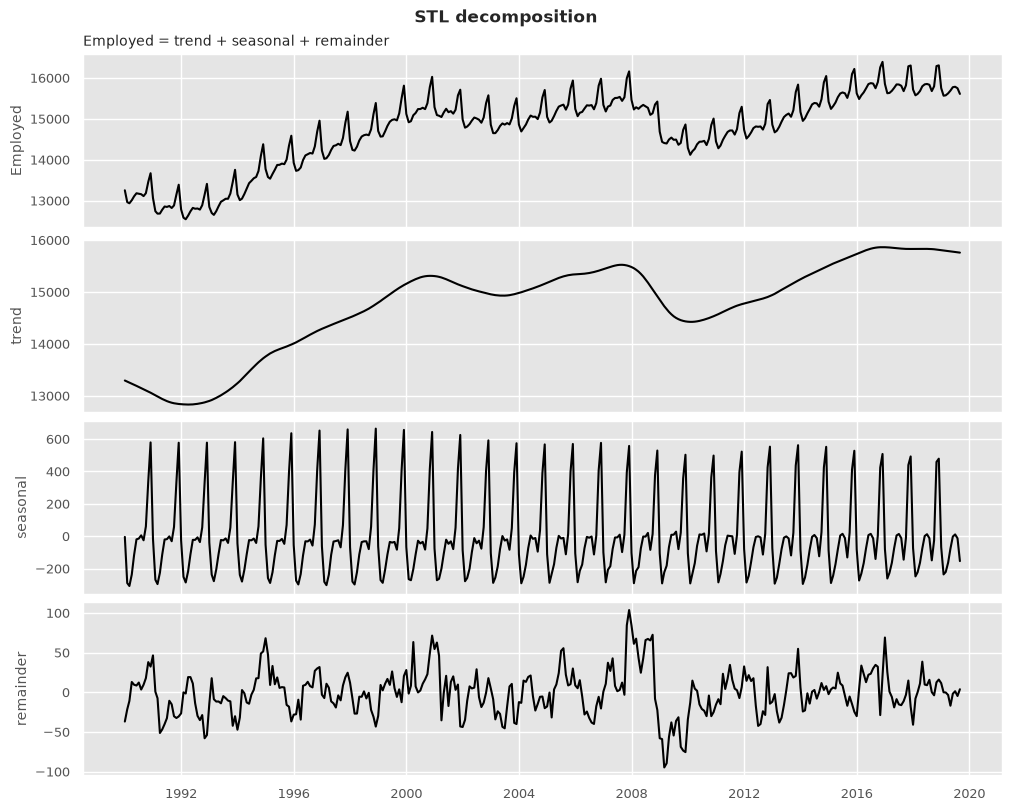

In [152]:
from statsmodels.tsa.seasonal import STL

stl = STL(us_retail_employment["y"], period=12)
res = stl.fit()
stl_dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res.trend,
    "seasonal": res.seasonal,
    "remainder": res.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
sns.lineplot(data=stl_dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=stl_dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=stl_dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=stl_dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + remainder", size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition",fontweight='bold')
plt.show()

The two main parameters to be chosen when using STL are the `season` and the `trend`. The season is the length of the seasonal smoother, while the trend is the length of the trend smoother. These parameters control how rapidly the <u>trend-cycle</u> and <u>seasonal components</u> can change. Smaller values allow for more rapid changes. Both trend and seasonal windows should be **odd** numbers.

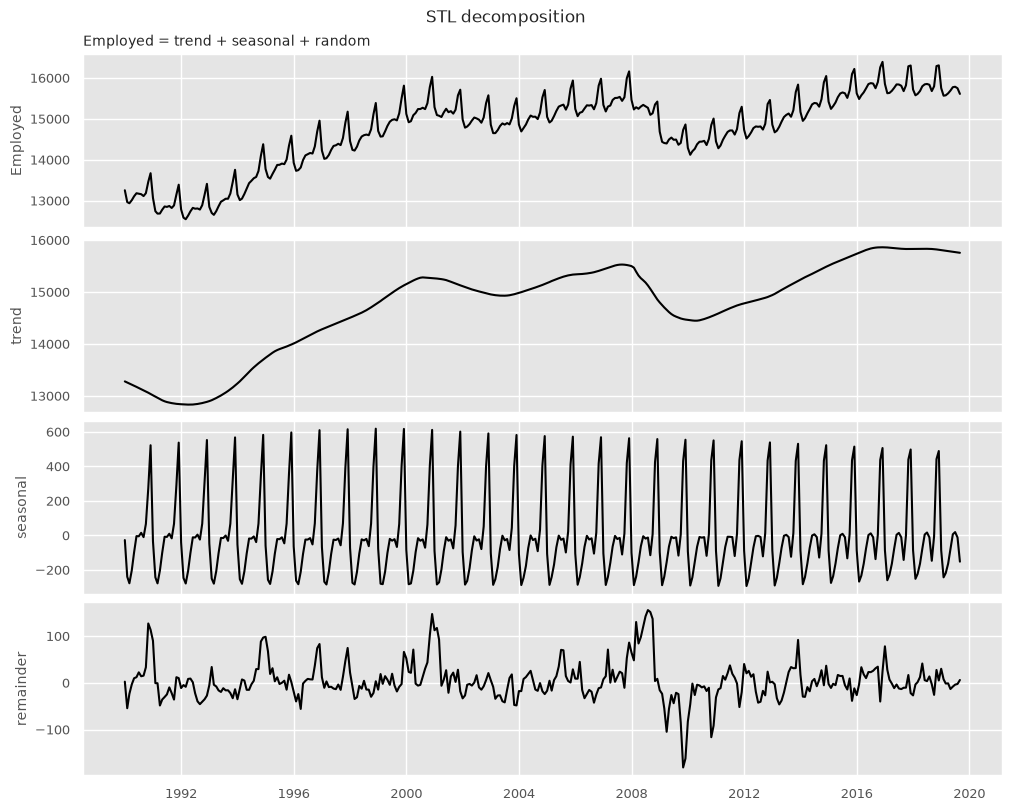

In [160]:
stl = STL(us_retail_employment["y"], period=12,
    seasonal=13, trend=21, robust=True)
res_stl = stl.fit()

stl_dcmp = pd.DataFrame({
    "ds": us_retail_employment["ds"],
    "data": us_retail_employment["y"],
    "trend": res_stl.trend,
    "seasonal": res_stl.seasonal,
    "remainder": res_stl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
sns.lineplot(data=stl_dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=stl_dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=stl_dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=stl_dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + random",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

The `STL()` function in `statsmodels` provides a convenient automated STL decomposition. This usually gives a good balance between overfitting the seasonality and allowing it to slowly change over time. In this case the default trend window setting produces a trend-cycle component that is too rigid. As a result, signal from the 2008 global financial crisis has leaked into the remainder component, as can be seen in the first output. Selecting a shorter trend window for the second case improves this.

##### **3. MSTL Decomposition**
<hr style="margin-top: -20px; border: none; border-top: 1px solid lightgrey;">
MSTL stands for Multiple Seasonal-Trend decomposition using Loess. It is a method to decompose a time series into a trend component, multiple seasonal components, and a residual component. MSTL builds on STL to iteratively extract each of the seasonal components.

Apart from other advantages of a STL, MSTL is useful because it is:

- Accurate, MSTL typically produced the lowest RMSE on a range of benchmark time series
- Computationally efficient, MSTL had the lowest execution time of all the methods compared
- MSTL can model seasonality which changes with time

**<span style="color:brown;">Decomposition</span>**

We break the decomposition part of the algorithm into multiple steps.

**<span style="color:grey;">Step 1: Extract and Refine each seasonal component using STL.</span>**

_Step 1.1: Extraction_
This is the distinguishable step of the algorithm. First, the algorithm iterates through each seasonal component starting from the shortest period (e.g., daily) to the longest period (e.g., yearly). On each iteration, it extracts the seasonal component via STL and then subtract it from the time series. It then passes the resulting de-seasonalised time series to the next iteration where it extracts the next seasonal component and so on until all seasonal components have been extracted.

_Step 1.2: Refinement_
It then iterates through each seasonal component again. On each iteration it adds this single seasonal component back to the fully de-seasonalised time series from the end of the previous step. Then it extracts the same seasonal component back from this time series using STL. It subtracts this new estimate of the seasonal component from the time series so that it is, once again, fully de-seasonalised.
<div style="display: flex; justify-content: center; align-items: center; gap: 25px;">
  <img src="images/1.png" style="width: 48%;">
  <img src="images/2.png" style="width: 48%;">
</div>

**<span style="color:grey;">Step 2: Extract the trend.</span>**

Extract the trend component from the last STL fit that occurs in Step 1.2 (i.e., for the longest period seasonal component).

**<span style="color:grey;">Step 3: Extract the residual</span>**

The residual component is calculated by subtracting the trend component from the fully de-seasonalised time series at the end of Step 1.2.

In [167]:
url = "https://raw.githubusercontent.com/tidyverts/tsibbledata/master/data-raw/vic_elec/VIC2015/demand.csv"
vic_elec = pd.read_csv(url)

## requires parsing of date as it's stored in Epoch-based time
vic_elec["Date"] = vic_elec["Date"].apply(
    lambda x: pd.Timestamp("1899-12-30") + pd.Timedelta(x, unit="days")
)

## extracting the 30-minute timestamp based on the Period
vic_elec["ds"] = vic_elec["Date"] + pd.to_timedelta((vic_elec["Period"] - 1) * 30, unit="m")

timeseries = vic_elec[["ds", "OperationalLessIndustrial"]]
timeseries.columns = [ "ds", "demand",]  # Rename to OperationalLessIndustrial to demand for simplicity.

# Filter for first 149 days of 2008.
start_date = pd.to_datetime("2008-01-01")
end_date = start_date + pd.Timedelta("149D")
filter = (timeseries["ds"] >= start_date) & (timeseries["ds"] < end_date)
timeseries = timeseries[filter]

# Resample to hourly
timeseries = timeseries.set_index("ds").resample("H").sum()
timeseries.head()

,demand
ds,
2008-01-01 00:00:00,9409.868
2008-01-01 01:00:00,9388.010
2008-01-01 02:00:00,8278.185
2008-01-01 03:00:00,7739.643
2008-01-01 04:00:00,7526.909


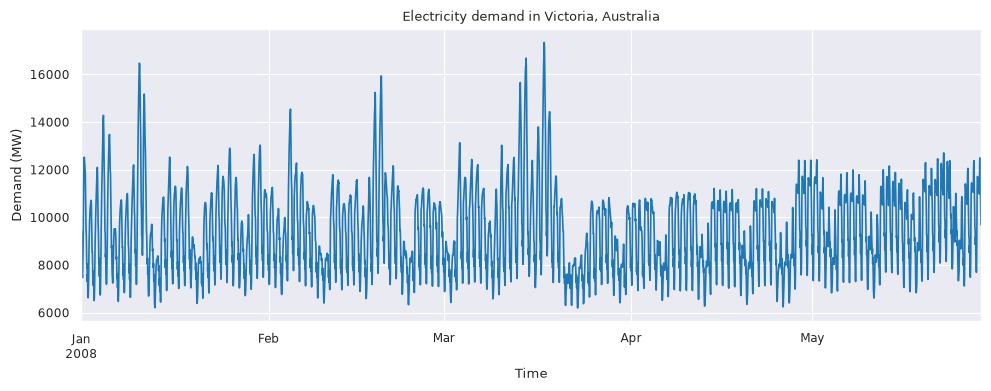

In [174]:
# Plot the time series
sns.set_style('darkgrid')
sns.set_context('paper')

ax = timeseries.plot(y="demand",color='tab:blue', figsize=[10, 4], legend=False)
ax.set_ylabel("Demand (MW)")
ax.set_xlabel("Time")
ax.set_title("Electricity demand in Victoria, Australia")
plt.tight_layout()

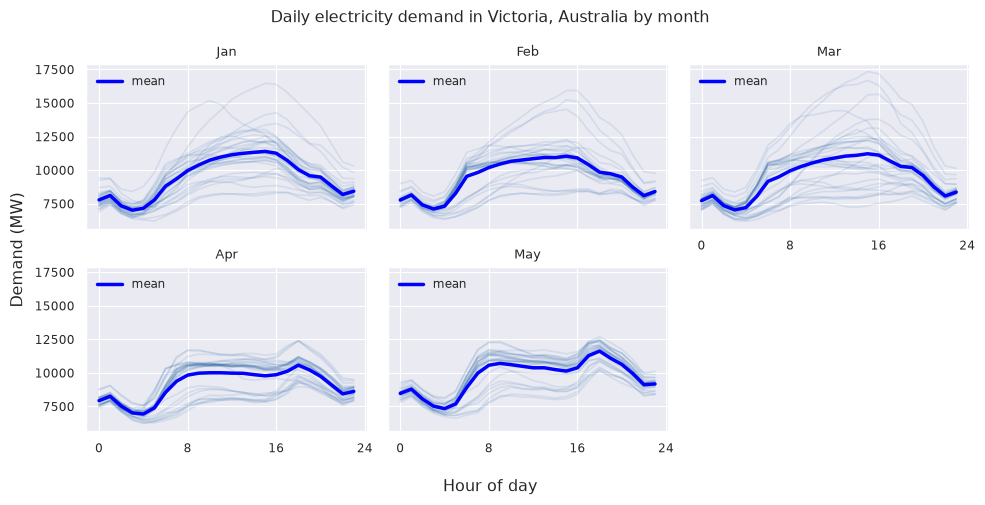

In [190]:
# Compute date time variables used later in plotting
timeseries["week"] = timeseries.index.isocalendar().week
timeseries["day_of_month"] = timeseries.index.day
timeseries["month"] = timeseries.index.month

# Plot the electricity demand for each day of the month
fig, ax = plt.subplots(2,3, figsize=[10, 5], sharey=True)
ax = ax.flatten()
sns_blue = sns.color_palette('Blues_r')[0]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May"]
for index, month in enumerate(MONTHS):

    # Create empty list to plot individual ts
    daily_ts = []
    # filter for each month and then aggregate using groupby
    filter_timeseries = timeseries[["demand", "day_of_month", "month"]].query(f"month == {index+1}").groupby("day_of_month")
    for _, ts in filter_timeseries:
        daily_ts.append(ts.reset_index()["demand"])
        ts.reset_index()["demand"].plot(
            alpha=0.1, ax=ax[index], color=sns_blue, label="_no_legend_"
        )
        ax[index].set_xticks(np.arange(0, len(ts) + 1, 8))
        ax[index].set_title(month)

    # Plot the mean ts
    pd.concat(daily_ts, axis=1).mean(axis=1).plot(
        ax=ax[index], color="blue", linewidth=2.5, label="mean", legend=True
    )
    ax[index].legend(loc="upper left", frameon=False)

    if month in ("Jan", "Feb"):
        ax[index].tick_params(
            axis="x", which="both", bottom=False, top=False, labelbottom=False
        )

fig.supxlabel("Hour of day", ha="center")
fig.supylabel("Demand (MW)", va="center")
fig.suptitle("Daily electricity demand in Victoria, Australia by month")
fig.delaxes(ax[-1])
fig.tight_layout()

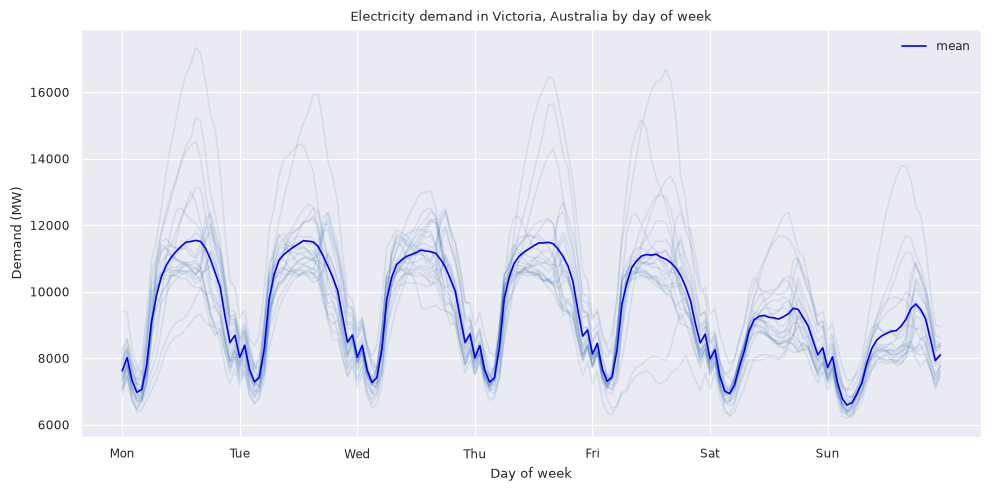

In [191]:
fig, ax = plt.subplots(figsize=[10, 5])
weekly_ts = []
DAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for week, ts in timeseries.groupby("week"):
    weekly_ts.append(ts.reset_index()["demand"])
    ts.reset_index()["demand"].plot(alpha=0.1, ax=ax, label="_no_legend_", color=sns_blue)
    plt.xticks(ticks=np.arange(0, 167, 24), labels=DAYS)

pd.concat(weekly_ts, axis=1).mean(axis=1).plot(
    ax=ax, color="blue", label="mean", legend=True
)

ax.set_ylabel("Demand (MW)")
ax.set_title("Electricity demand in Victoria, Australia by day of week")
ax.set_xlabel("Day of week")
ax.legend(loc="upper right", frameon=False)

plt.tight_layout()

In [192]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(timeseries["demand"], periods=(24, 24 * 7), stl_kwargs={"seasonal_deg": 0})
res_mstl = mstl.fit()

mstl_dcmp = pd.DataFrame({
    "ds": timeseries.index,
    "data": timeseries["demand"],
    "trend": res_mstl.trend,
    "seasonal": res_mstl.seasonal,
    "remainder": res_mstl.resid,
}).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
sns.lineplot(data=mstl_dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=mstl_dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=mstl_dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=mstl_dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Electricity Demand = trend + seasonal + random",
    size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

KeyboardInterrupt: 